In [7]:
"""Sweep cue_fraction for a single sparse fear engram and plot mean retrieval overlap.
Key parameters: n_neurons, sparsity, corruption_level, beta, theta, cue_fractions, n_trials.
"""
import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import generate_sparse_pattern, corrupt_pattern, generate_cs_input
from engram.hopfield import HopfieldNetwork
from engram.metrics import pattern_overlap, retrieval_success

n_neurons = 2000
sparsity = 0.1
corruption_level = 0.6
beta = 1.0
theta = 0.0

cue_fractions = np.linspace(0.1, 1.0, 10)
n_trials = 20

mean_overlaps = []
mean_successes = []

for cue_fraction in cue_fractions:
    overlaps = []
    successes = []

    for trial in range(n_trials):
        rng = np.random.default_rng(trial)

        pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
        corrupted = corrupt_pattern(pattern, corruption_level, rng=rng)
        cs_input = generate_cs_input(pattern, cue_fraction, rng=rng)

        net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
        net.store_patterns([pattern])

        final_state, trajectory = net.run(
            initial_state=corrupted,
            external_input=cs_input,
            beta=beta,
            theta=theta,
        )

        overlaps.append(pattern_overlap(final_state, pattern))
        successes.append(retrieval_success(final_state, pattern, threshold=0.9))

    mean_overlaps.append(np.mean(overlaps))
    mean_successes.append(np.mean(successes))

plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_overlaps, marker="o")
plt.xlabel("Cue fraction")
plt.ylabel("Mean final overlap")
plt.title("Retrieval vs cue fraction")
plt.ylim(0, 1.05)
plt.show()

AttributeError: 'HopfieldNetwork' object has no attribute 'run'

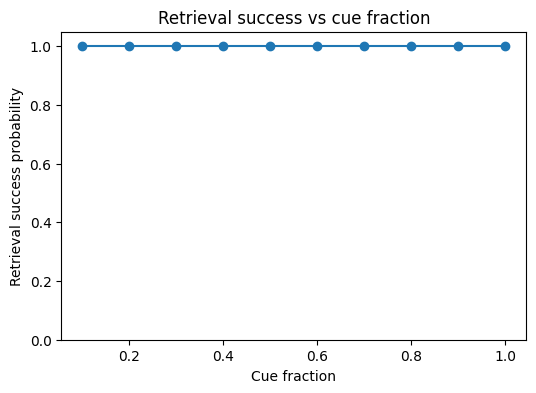

In [ ]:
"""Plot retrieval success probability vs cue_fraction for the first experiment.
Uses mean_successes computed over n_trials at each cue_fraction.
"""
plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_successes, marker="o")
plt.xlabel("Cue fraction")
plt.ylabel("Retrieval success probability")
plt.title("Retrieval success vs cue fraction")
plt.ylim(0, 1.05)
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import (
    generate_sparse_pattern,
    corrupt_pattern,
    generate_noisy_cs_input,
)
from engram.hopfield import HopfieldNetwork
from engram.metrics import (
    pattern_overlap,
    retrieval_success,
    activity_fraction,
    convergence_steps,
)

# -------------------------
# Fixed parameters
# -------------------------
n_neurons = 2000
sparsity = 0.10
corruption_level = 0.70
beta = 1.0
theta = 0.0
background_fraction = 0.20
n_trials = 20

cue_fractions = np.linspace(0.1, 1.0, 10)

mean_overlaps = []
mean_successes = []
mean_final_activity = []
mean_steps = []

for cue_fraction in cue_fractions:
    overlaps = []
    successes = []
    activities = []
    steps_list = []

    for trial in range(n_trials):
        rng = np.random.default_rng(10000 + trial)

        pattern = generate_sparse_pattern(
            n_neurons=n_neurons,
            sparsity=sparsity,
            rng=rng,
        )

        # Start from zero state so the cue does the retrieval work
        initial_state = np.zeros(n_neurons, dtype=int)

        cs_input = generate_noisy_cs_input(
            pattern=pattern,
            cue_fraction=cue_fraction,
            background_fraction=background_fraction,
            rng=rng,
        )

        net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
        net.store_patterns([pattern])

        final_state, trajectory = net.run(
            initial_state=initial_state,
            external_input=cs_input,
            beta=beta,
            theta=theta,
            max_steps=50,
        )

        overlaps.append(pattern_overlap(final_state, pattern))
        successes.append(retrieval_success(final_state, pattern, threshold=0.9))
        activities.append(activity_fraction(final_state))
        steps_list.append(convergence_steps(trajectory))

    mean_overlaps.append(np.mean(overlaps))
    mean_successes.append(np.mean(successes))
    mean_final_activity.append(np.mean(activities))
    mean_steps.append(np.mean(steps_list))

# -------------------------
# Plot 1: overlap
# -------------------------
plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_overlaps, marker="o")
plt.xlabel("Cue fraction onto engram")
plt.ylabel("Mean final overlap")
plt.title("Retrieval vs cue fraction")
plt.ylim(0, 1.05)
plt.show()

# -------------------------
# Plot 2: success
# -------------------------
plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_successes, marker="o")
plt.xlabel("Cue fraction onto engram")
plt.ylabel("Retrieval success probability")
plt.title("Retrieval success vs cue fraction")
plt.ylim(0, 1.05)
plt.show()

# -------------------------
# Plot 3: final activity
# -------------------------
plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_final_activity, marker="o")
plt.xlabel("Cue fraction onto engram")
plt.ylabel("Final activity fraction")
plt.title("Final network activity vs cue fraction")
plt.ylim(0, 1.05)
plt.show()

# -------------------------
# Plot 4: convergence steps
# -------------------------
plt.figure(figsize=(6, 4))
plt.plot(cue_fractions, mean_steps, marker="o")
plt.xlabel("Cue fraction onto engram")
plt.ylabel("Mean convergence steps")
plt.title("Convergence vs cue fraction")
plt.show()

AttributeError: 'HopfieldNetwork' object has no attribute 'run'

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import generate_sparse_pattern, generate_noisy_cs_input
from engram.hopfield import HopfieldNetwork
from engram.metrics import pattern_overlap

rng = np.random.default_rng(42)

n_neurons = 2000
sparsity = 0.10
cue_fraction = 0.30
background_fraction = 0.05
beta = 0.5
theta = 0.2

pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
initial_state = np.zeros(n_neurons, dtype=int)

cs_input = generate_noisy_cs_input(
    pattern=pattern,
    cue_fraction=cue_fraction,
    background_fraction=background_fraction,
    rng=rng,
)

net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
net.store_patterns([pattern])

final_state, trajectory, energies = net.run_asynchronous(
    initial_state=initial_state,
    external_input=cs_input,
    beta=beta,
    theta=theta,
    n_sweeps=20,
    rng=rng,
)

overlaps = [pattern_overlap(state, pattern) for state in trajectory]

print("Final overlap:", pattern_overlap(final_state, pattern))
print("Final activity fraction:", final_state.mean())
print("Number of sweeps:", len(trajectory) - 1)

Final overlap: 1.0
Final activity fraction: 0.145
Number of sweeps: 3


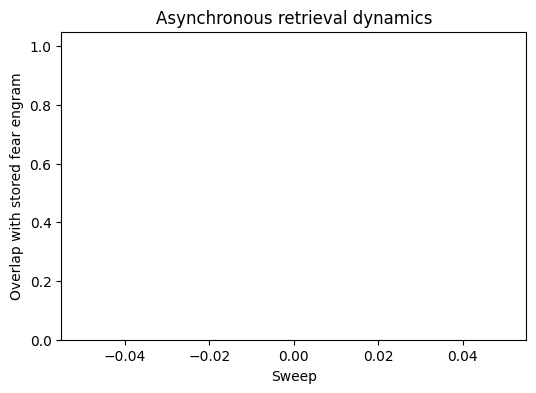

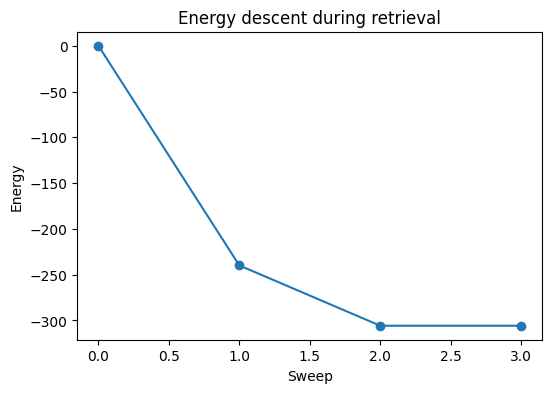

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(overlaps, marker="o")
plt.xlabel("Sweep")
plt.ylabel("Overlap with stored fear engram")
plt.title("Asynchronous retrieval dynamics")
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(energies, marker="o")
plt.xlabel("Sweep")
plt.ylabel("Energy")
plt.title("Energy descent during retrieval")
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import generate_sparse_pattern, generate_noisy_cs_input
from engram.hopfield import HopfieldNetwork
from engram.metrics import (
    pattern_overlap,
    retrieval_success,
    activity_fraction,
    convergence_steps,
)

n_neurons = 2000
sparsity = 0.10
cue_fraction = 0.30
background_fraction = 0.05
theta = 0.2
n_trials = 20

betas = np.linspace(0.0, 1.5, 10)

mean_overlaps = []
mean_successes = []
mean_activities = []
mean_steps = []

for beta in betas:
    overlaps = []
    successes = []
    activities = []
    steps_list = []

    for trial in range(n_trials):
        rng = np.random.default_rng(5000 + trial)

        pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
        initial_state = np.zeros(n_neurons, dtype=int)

        cs_input = generate_noisy_cs_input(
            pattern=pattern,
            cue_fraction=cue_fraction,
            background_fraction=background_fraction,
            rng=rng,
        )

        net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
        net.store_patterns([pattern])

        final_state, trajectory, energies = net.run_asynchronous(
            initial_state=initial_state,
            external_input=cs_input,
            beta=beta,
            theta=theta,
            n_sweeps=20,
            rng=rng,
        )

        overlaps.append(pattern_overlap(final_state, pattern))
        successes.append(retrieval_success(final_state, pattern, threshold=0.9))
        activities.append(activity_fraction(final_state))
        steps_list.append(convergence_steps(trajectory))

    mean_overlaps.append(np.mean(overlaps))
    mean_successes.append(np.mean(successes))
    mean_activities.append(np.mean(activities))
    mean_steps.append(np.mean(steps_list))

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import generate_sparse_pattern, generate_noisy_cs_input
from engram.hopfield import HopfieldNetwork
from engram.metrics import (
    pattern_overlap,
    retrieval_success,
    activity_fraction,
    convergence_steps,
)

n_neurons = 2000
sparsity = 0.10
cue_fraction = 0.25
background_fraction = 0.08
theta = 0.3
n_trials = 20

betas = np.linspace(0.0, 1.5, 10)

mean_overlaps = []
mean_successes = []
mean_activities = []
mean_steps = []

for beta in betas:
    overlaps = []
    successes = []
    activities = []
    steps_list = []

    for trial in range(n_trials):
        rng = np.random.default_rng(5000 + trial)

        pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
        initial_state = np.zeros(n_neurons, dtype=int)

        cs_input = generate_noisy_cs_input(
            pattern=pattern,
            cue_fraction=cue_fraction,
            background_fraction=background_fraction,
            rng=rng,
        )

        net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
        net.store_patterns([pattern])

        final_state, trajectory, energies = net.run_asynchronous(
            initial_state=initial_state,
            external_input=cs_input,
            beta=beta,
            theta=theta,
            n_sweeps=20,
            rng=rng,
        )

        overlaps.append(pattern_overlap(final_state, pattern))
        successes.append(retrieval_success(final_state, pattern, threshold=0.9))
        activities.append(activity_fraction(final_state))
        steps_list.append(convergence_steps(trajectory))

    mean_overlaps.append(np.mean(overlaps))
    mean_successes.append(np.mean(successes))
    mean_activities.append(np.mean(activities))
    mean_steps.append(np.mean(steps_list))

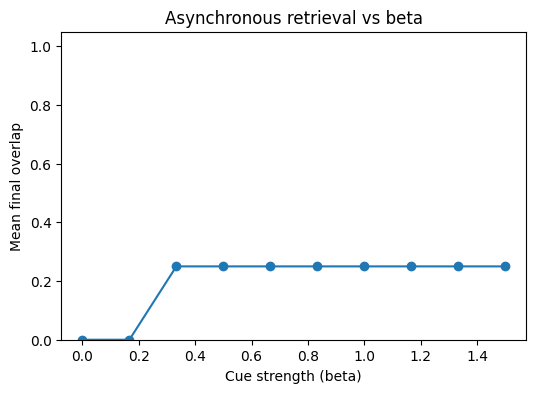

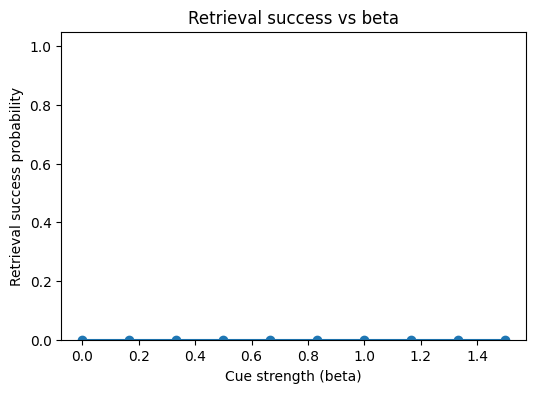

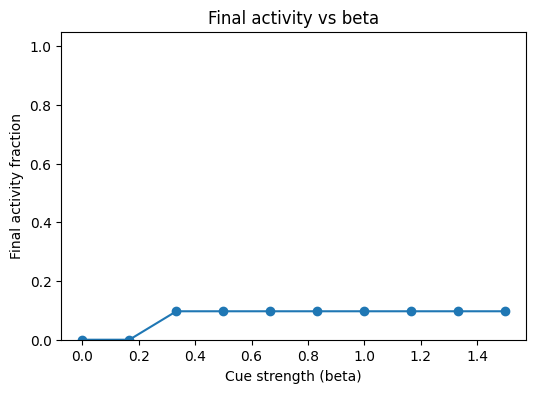

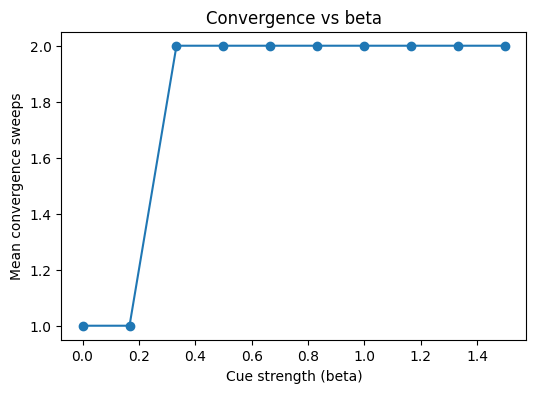

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(betas, mean_overlaps, marker="o")
plt.xlabel("Cue strength (beta)")
plt.ylabel("Mean final overlap")
plt.title("Asynchronous retrieval vs beta")
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(betas, mean_successes, marker="o")
plt.xlabel("Cue strength (beta)")
plt.ylabel("Retrieval success probability")
plt.title("Retrieval success vs beta")
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(betas, mean_activities, marker="o")
plt.xlabel("Cue strength (beta)")
plt.ylabel("Final activity fraction")
plt.title("Final activity vs beta")
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(betas, mean_steps, marker="o")
plt.xlabel("Cue strength (beta)")
plt.ylabel("Mean convergence sweeps")
plt.title("Convergence vs beta")
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import generate_sparse_pattern, generate_noisy_cs_input
from engram.hopfield import HopfieldNetwork
from engram.metrics import pattern_overlap, retrieval_success

# Fixed parameters
n_neurons = 2000
sparsity = 0.10
background_fraction = 0.08
beta = 1.0
n_trials = 20

cue_fractions = np.linspace(0.1, 0.6, 11)
thetas = np.linspace(0.05, 0.35, 7)

mean_overlap_heatmap = np.zeros((len(thetas), len(cue_fractions)))
success_heatmap = np.zeros((len(thetas), len(cue_fractions)))

for i, theta in enumerate(thetas):
    for j, cue_fraction in enumerate(cue_fractions):
        overlaps = []
        successes = []

        for trial in range(n_trials):
            rng = np.random.default_rng(7000 + 100 * i + trial)

            pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
            initial_state = np.zeros(n_neurons, dtype=int)

            cs_input = generate_noisy_cs_input(
                pattern=pattern,
                cue_fraction=cue_fraction,
                background_fraction=background_fraction,
                rng=rng,
            )

            net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
            net.store_patterns([pattern])

            final_state, trajectory, energies = net.run_asynchronous(
                initial_state=initial_state,
                external_input=cs_input,
                beta=beta,
                theta=theta,
                n_sweeps=20,
                rng=rng,
            )

            overlaps.append(pattern_overlap(final_state, pattern))
            successes.append(retrieval_success(final_state, pattern, threshold=0.9))

        mean_overlap_heatmap[i, j] = np.mean(overlaps)
        success_heatmap[i, j] = np.mean(successes)

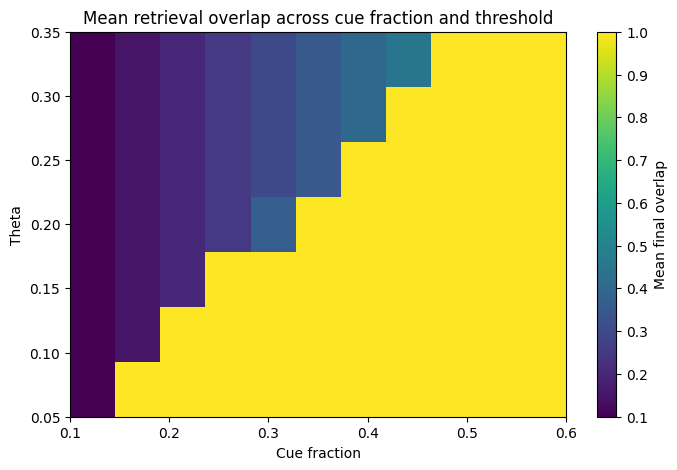

In [20]:
plt.figure(figsize=(8, 5))
plt.imshow(
    mean_overlap_heatmap,
    aspect="auto",
    origin="lower",
    extent=[cue_fractions.min(), cue_fractions.max(), thetas.min(), thetas.max()],
)
plt.colorbar(label="Mean final overlap")
plt.xlabel("Cue fraction")
plt.ylabel("Theta")
plt.title("Mean retrieval overlap across cue fraction and threshold")
plt.show()

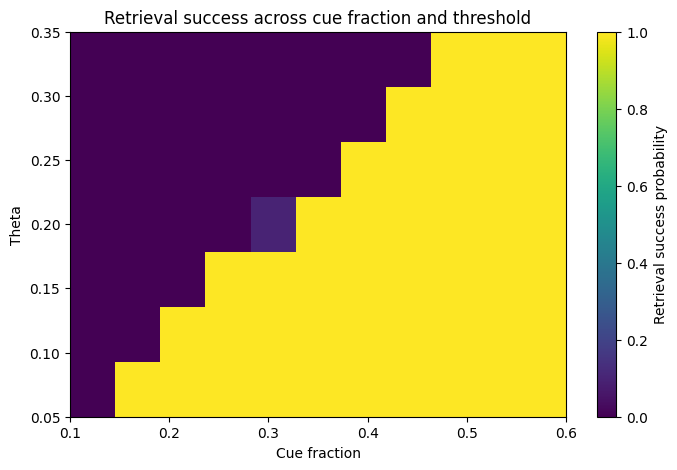

: 

In [ ]:
plt.figure(figsize=(8, 5))
plt.imshow(
    success_heatmap,
    aspect="auto",
    origin="lower",
    extent=[cue_fractions.min(), cue_fractions.max(), thetas.min(), thetas.max()],
)
plt.colorbar(label="Retrieval success probability")
plt.xlabel("Cue fraction")
plt.ylabel("Theta")
plt.title("Retrieval success across cue fraction and threshold")
plt.show()

In [1]:
# background noise robustness

import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import generate_sparse_pattern, generate_noisy_cs_input
from engram.hopfield import HopfieldNetwork
from engram.metrics import pattern_overlap, retrieval_success

# Fixed parameters
n_neurons = 2000
sparsity = 0.10
beta = 1.0
theta = 0.20
n_trials = 20

cue_fractions = np.linspace(0.1, 0.6, 11)
background_fractions = np.linspace(0.0, 0.20, 11)

mean_overlap_heatmap_bg = np.zeros((len(background_fractions), len(cue_fractions)))
success_heatmap_bg = np.zeros((len(background_fractions), len(cue_fractions)))

for i, background_fraction in enumerate(background_fractions):
    for j, cue_fraction in enumerate(cue_fractions):
        overlaps = []
        successes = []

        for trial in range(n_trials):
            rng = np.random.default_rng(9000 + 100 * i + trial)

            pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
            initial_state = np.zeros(n_neurons, dtype=int)

            cs_input = generate_noisy_cs_input(
                pattern=pattern,
                cue_fraction=cue_fraction,
                background_fraction=background_fraction,
                rng=rng,
            )

            net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
            net.store_patterns([pattern])

            final_state, trajectory, energies = net.run_asynchronous(
                initial_state=initial_state,
                external_input=cs_input,
                beta=beta,
                theta=theta,
                n_sweeps=20,
                rng=rng,
            )

            overlaps.append(pattern_overlap(final_state, pattern))
            successes.append(retrieval_success(final_state, pattern, threshold=0.9))

        mean_overlap_heatmap_bg[i, j] = np.mean(overlaps)
        success_heatmap_bg[i, j] = np.mean(successes)

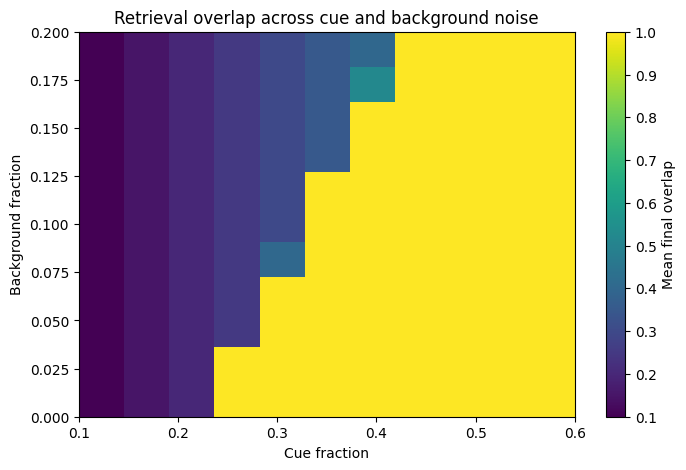

In [3]:
plt.figure(figsize=(8, 5))
plt.imshow(
    mean_overlap_heatmap_bg,
    aspect="auto",
    origin="lower",
    extent=[
        cue_fractions.min(),
        cue_fractions.max(),
        background_fractions.min(),
        background_fractions.max(),
    ],
)
plt.colorbar(label="Mean final overlap")
plt.xlabel("Cue fraction")
plt.ylabel("Background fraction")
plt.title("Retrieval overlap across cue and background noise")
plt.show()

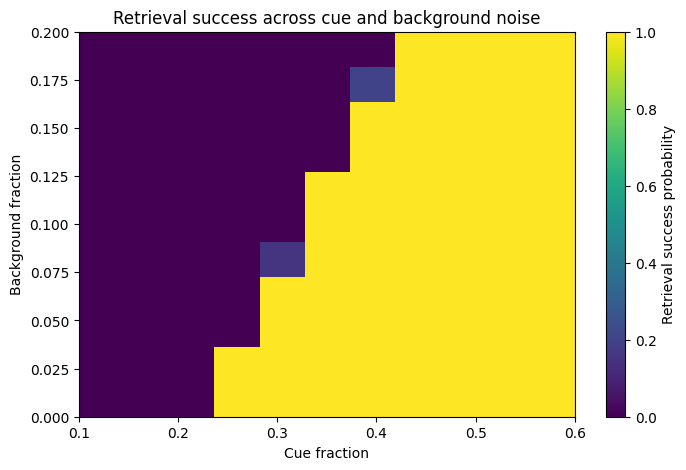

In [4]:
plt.figure(figsize=(8, 5))
plt.imshow(
    success_heatmap_bg,
    aspect="auto",
    origin="lower",
    extent=[
        cue_fractions.min(),
        cue_fractions.max(),
        background_fractions.min(),
        background_fractions.max(),
    ],
)
plt.colorbar(label="Retrieval success probability")
plt.xlabel("Cue fraction")
plt.ylabel("Background fraction")
plt.title("Retrieval success across cue and background noise")
plt.show()

DYNAMICS NEAR THE BOUNDARY

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import generate_sparse_pattern, generate_noisy_cs_input
from engram.hopfield import HopfieldNetwork
from engram.metrics import pattern_overlap, activity_fraction

# Boundary-ish operating point
n_neurons = 2000
sparsity = 0.10
cue_fraction = 0.30
background_fraction = 0.08
beta = 1.0
theta = 0.20

n_examples = 10

all_overlaps = []
all_energies = []
all_activities = []
n_sweeps_list = []

for example_idx in range(n_examples):
    rng = np.random.default_rng(12000 + example_idx)

    pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
    initial_state = np.zeros(n_neurons, dtype=int)

    cs_input = generate_noisy_cs_input(
        pattern=pattern,
        cue_fraction=cue_fraction,
        background_fraction=background_fraction,
        rng=rng,
    )

    net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
    net.store_patterns([pattern])

    final_state, trajectory, energies = net.run_asynchronous(
        initial_state=initial_state,
        external_input=cs_input,
        beta=beta,
        theta=theta,
        n_sweeps=20,
        rng=rng,
    )

    overlaps = [pattern_overlap(state, pattern) for state in trajectory]
    activities = [activity_fraction(state) for state in trajectory]

    all_overlaps.append(overlaps)
    all_energies.append(energies)
    all_activities.append(activities)
    n_sweeps_list.append(len(trajectory) - 1)

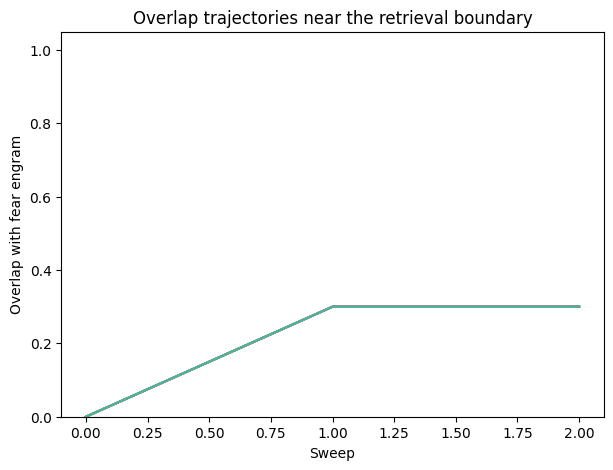

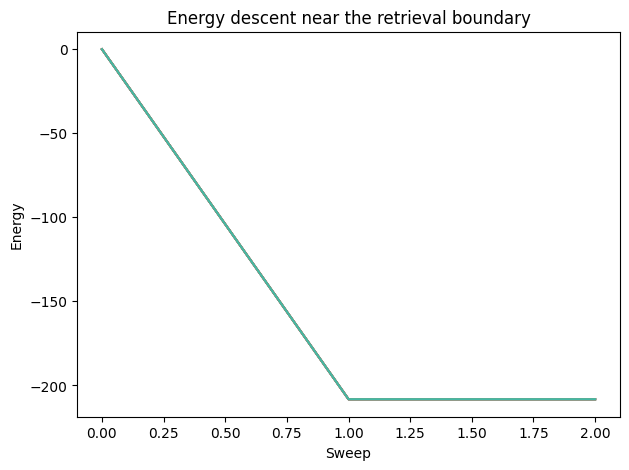

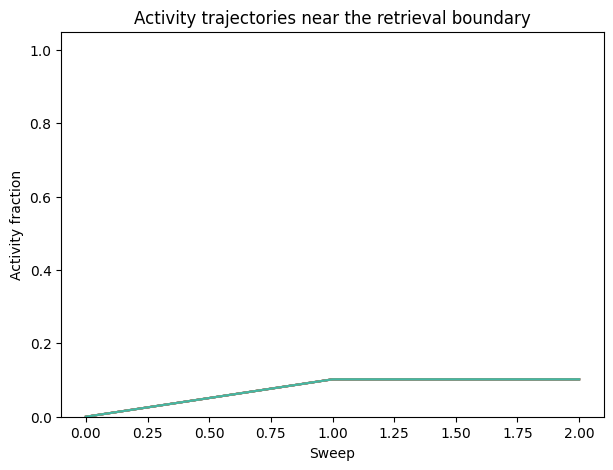

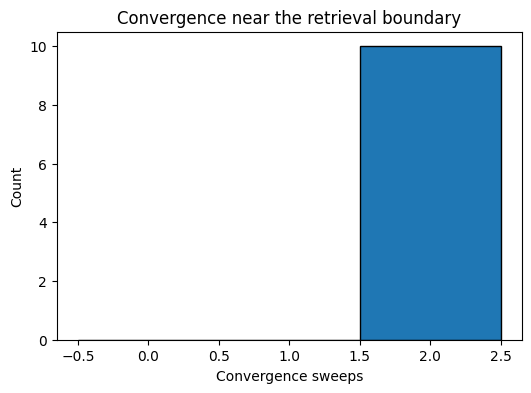

Mean convergence sweeps: 2.0
Min convergence sweeps: 2
Max convergence sweeps: 2


In [6]:
plt.figure(figsize=(7, 5))
for overlaps in all_overlaps:
    plt.plot(overlaps, alpha=0.7)
plt.xlabel("Sweep")
plt.ylabel("Overlap with fear engram")
plt.title("Overlap trajectories near the retrieval boundary")
plt.ylim(0, 1.05)
plt.show()


plt.figure(figsize=(7, 5))
for energies in all_energies:
    plt.plot(energies, alpha=0.7)
plt.xlabel("Sweep")
plt.ylabel("Energy")
plt.title("Energy descent near the retrieval boundary")
plt.show()

plt.figure(figsize=(7, 5))
for activities in all_activities:
    plt.plot(activities, alpha=0.7)
plt.xlabel("Sweep")
plt.ylabel("Activity fraction")
plt.title("Activity trajectories near the retrieval boundary")
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(n_sweeps_list, bins=np.arange(0, max(n_sweeps_list) + 2) - 0.5, edgecolor="black")
plt.xlabel("Convergence sweeps")
plt.ylabel("Count")
plt.title("Convergence near the retrieval boundary")
plt.show()

print("Mean convergence sweeps:", np.mean(n_sweeps_list))
print("Min convergence sweeps:", np.min(n_sweeps_list))
print("Max convergence sweeps:", np.max(n_sweeps_list))

TRYING A SECOND PATTERN

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import generate_sparse_pattern, generate_noisy_cs_input
from engram.hopfield import HopfieldNetwork
from engram.metrics import pattern_overlap, retrieval_success, activity_fraction

# Fixed parameters
n_neurons = 2000
sparsity = 0.10
cue_fraction = 0.30
background_fraction = 0.08
beta = 1.0
theta = 0.20
n_trials = 30

n_additional_patterns_values = [1, 5, 10, 20, 40, 80, 120, 200, 400, 600]

mean_overlap_load = []
mean_success_load = []
mean_activity_load = []

for n_extra in n_additional_patterns_values:
    overlaps = []
    successes = []
    activities = []

    for trial in range(n_trials):
        rng = np.random.default_rng(15000 + 100 * n_extra + trial)

        fear_pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
        extra_patterns = [
            generate_sparse_pattern(n_neurons, sparsity, rng=rng)
            for _ in range(n_extra)
        ]

        all_patterns = [fear_pattern] + extra_patterns

        initial_state = np.zeros(n_neurons, dtype=int)

        cs_input = generate_noisy_cs_input(
            pattern=fear_pattern,
            cue_fraction=cue_fraction,
            background_fraction=background_fraction,
            rng=rng,
        )

        net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
        net.store_patterns(all_patterns)

        final_state, trajectory, energies = net.run_asynchronous(
            initial_state=initial_state,
            external_input=cs_input,
            beta=beta,
            theta=theta,
            n_sweeps=20,
            rng=rng,
        )

        overlaps.append(pattern_overlap(final_state, fear_pattern))
        successes.append(retrieval_success(final_state, fear_pattern, threshold=0.9))
        activities.append(activity_fraction(final_state))

    mean_overlap_load.append(np.mean(overlaps))
    mean_success_load.append(np.mean(successes))
    mean_activity_load.append(np.mean(activities))

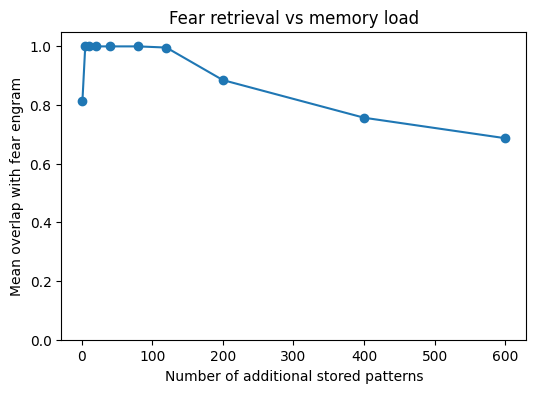

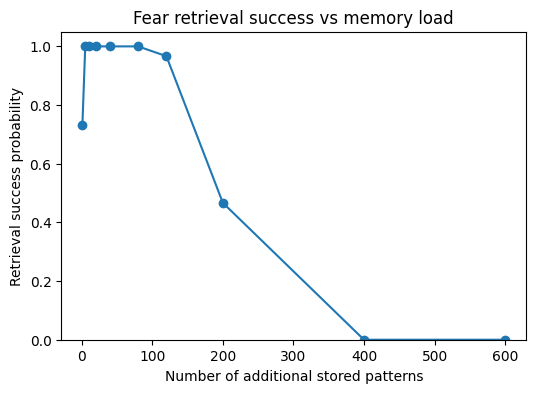

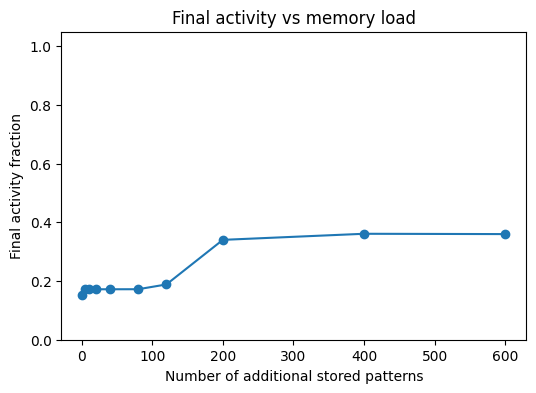

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(n_additional_patterns_values, mean_overlap_load, marker="o")
plt.xlabel("Number of additional stored patterns")
plt.ylabel("Mean overlap with fear engram")
plt.title("Fear retrieval vs memory load")
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(n_additional_patterns_values, mean_success_load, marker="o")
plt.xlabel("Number of additional stored patterns")
plt.ylabel("Retrieval success probability")
plt.title("Fear retrieval success vs memory load")
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(n_additional_patterns_values, mean_activity_load, marker="o")
plt.xlabel("Number of additional stored patterns")
plt.ylabel("Final activity fraction")
plt.title("Final activity vs memory load")
plt.ylim(0, 1.05)
plt.show()


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from engram.patterns import generate_sparse_pattern, generate_noisy_cs_input
from engram.hopfield import HopfieldNetwork
from engram.metrics import pattern_overlap, retrieval_success

# Boundary-ish parameters
n_neurons = 2000
sparsity = 0.10
cue_fraction = 0.30
background_fraction = 0.08
theta = 0.20
n_trials = 20

betas = np.linspace(0.2, 1.5, 10)

mean_overlap_beta_boundary = []
mean_success_beta_boundary = []

for beta in betas:
    overlaps = []
    successes = []

    for trial in range(n_trials):
        rng = np.random.default_rng(18000 + trial)

        pattern = generate_sparse_pattern(n_neurons, sparsity, rng=rng)
        initial_state = np.zeros(n_neurons, dtype=int)

        cs_input = generate_noisy_cs_input(
            pattern=pattern,
            cue_fraction=cue_fraction,
            background_fraction=background_fraction,
            rng=rng,
        )

        net = HopfieldNetwork(n_neurons=n_neurons, sparsity=sparsity)
        net.store_patterns([pattern])

        final_state, trajectory, energies = net.run_asynchronous(
            initial_state=initial_state,
            external_input=cs_input,
            beta=beta,
            theta=theta,
            n_sweeps=20,
            rng=rng,
        )

        overlaps.append(pattern_overlap(final_state, pattern))
        successes.append(retrieval_success(final_state, pattern, threshold=0.9))

    mean_overlap_beta_boundary.append(np.mean(overlaps))
    mean_success_beta_boundary.append(np.mean(successes))

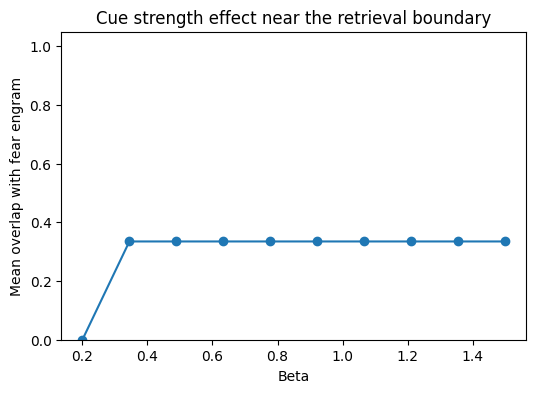

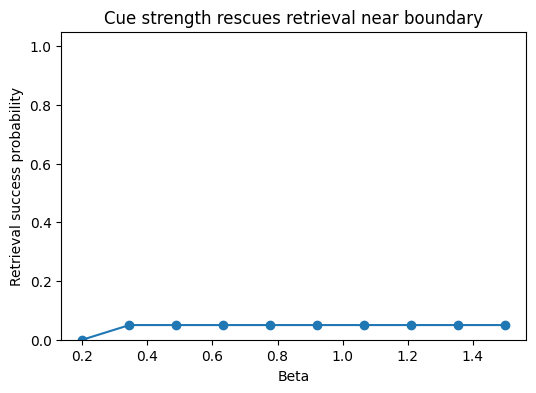

: 

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(betas, mean_overlap_beta_boundary, marker="o")
plt.xlabel("Beta")
plt.ylabel("Mean overlap with fear engram")
plt.title("Cue strength effect near the retrieval boundary")
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(betas, mean_success_beta_boundary, marker="o")
plt.xlabel("Beta")
plt.ylabel("Retrieval success probability")
plt.title("Cue strength rescues retrieval near boundary")
plt.ylim(0, 1.05)
plt.show()